# Convolution implementation in Python

First we import the necessary modules.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Now we define the input $I$ and the two kernels $k_1$ and $k_2$

In [2]:
# TODO: Define the image ...
image = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 5, 13, 9, 1, 0, 0],
    [0, 0, 13, 20, 10, 15, 5, 0],
    [0, 3, 15, 2, 0, 11, 8, 0],
    [0, 4, 11, 0, 1, 12, 7, 0],
    [0, 2, 14, 5, 10, 12, 0, 0],
    [0, 0, 6, 16, 10, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0]
], dtype=float)

# ... and the two kernels
k1 = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=float) * 0.05

k2 = np.array([
    [0, 1, 0],
    [0, 1, 0],
    [0, 1, 0]
], dtype=float) * 0.25

Now we come to the convolution operation:

In [3]:
def do_convolution(image, kernel, stride, padding):
    # image is pre-padded, therefore we don't have to care about the padding here
    result_dim = int((image.shape[0] - kernel.shape[0]) / stride + 1)
    result = np.zeros([result_dim, result_dim])

    for i1 in range(result_dim):
        for i2 in range(result_dim):
            sum = 0
            for k1 in range(kernel.shape[0]):
                for k2 in range(kernel.shape[0]):
                    # TODO: Set the correct indices
                    sum += image[i1 * stride + k1, i2 * stride + k2] * kernel[k1, k2]
            result[i1, i2] = sum

    return result

Let's compute the convolutions you previously calculated by hand.

In [4]:
conv1 = do_convolution(image, k1, 1, 1)
conv2 = do_convolution(image, k2, 1, 1)
conv3 = do_convolution(image, k2, 2, 1)

In [8]:
# I am adding this code block myself for me to compare my answers with my handwritten solutions
output_k1 = do_convolution(image, k1, stride=1, padding=0)
print("k1:")
print(output_k1)
print("\n" + "\n")

output_k2 = do_convolution(image, k2, stride=2, padding=0)
print("k2:")
print(output_k2)

k1:
[[1.15 4.6  7.15 5.95 3.35 1.35]
 [2.6  7.5  9.25 7.75 6.55 3.9 ]
 [3.7  7.1  5.65 4.75 6.85 5.25]
 [3.85 6.1  3.85 3.9  6.4  4.55]
 [3.05 6.2  6.4  6.2  5.5  2.5 ]
 [1.5  4.55 6.5  5.45 2.7  0.6 ]]



k2:
[[0.   8.25 4.  ]
 [1.75 5.5  9.5 ]
 [1.5  5.25 6.  ]]


Now we plot the image $I$ and the two outputs $I * k_1$ and $I * k_2$.

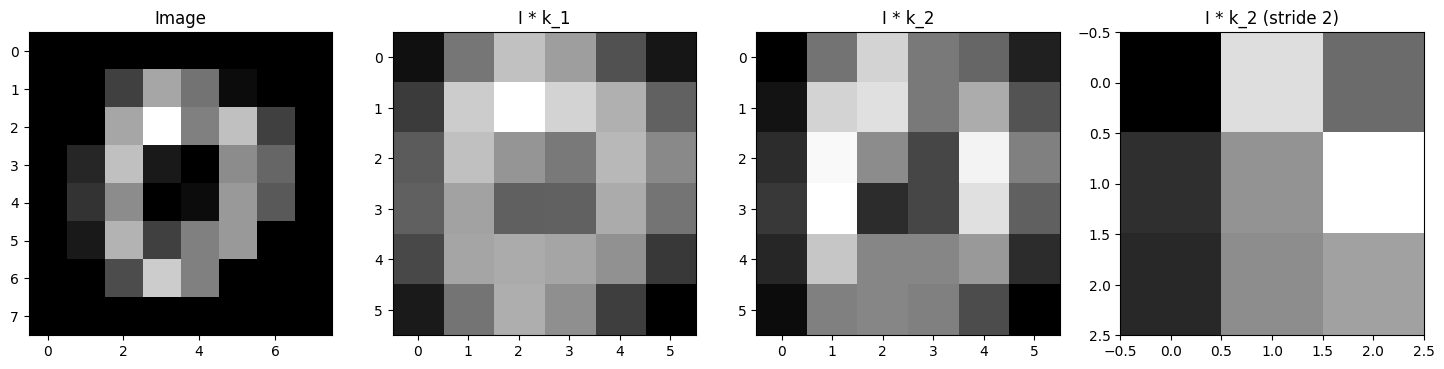

In [9]:
# Plot image and convolution output
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18, 16))
ax1.imshow(image, cmap='gray')
ax1.set_title("Image")
ax2.imshow(conv1, cmap='gray')
ax2.set_title("I * k_1")
ax3.imshow(conv2, cmap='gray')
ax3.set_title("I * k_2")
ax4.imshow(conv3, cmap='gray')
ax4.set_title("I * k_2 (stride 2)")
plt.show()

The values of $k_1$ are the ones of a discrete gauss kernel and $k_2$ represents and edge detector. It is therefore no suprize that given the image on the most left side, we can see that the convolution with $k_1$ leads to a blurred version of the image. The convolution with $k_2$ indicates the two vertical edges (represented by the four white pixels). Unfortunately the convolution with $k_2$ with a stride of 2 doesn't give us an intuitive result. 